<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

### **Entorno y setup del Drive**

Antes de entrenar dejamos preparado dónde se guardan datos, checkpoints, historiales y predicciones. Estoy usando el kernel de google colab en vscode, si se me reinicia o vence el server pierdo todo (ya me paso)

In [99]:
import json
import pickle
import random
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

sns.set_theme(style='whitegrid')

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/NLP/Desafio_4')
except ModuleNotFoundError:
    BASE_DIR = Path.cwd() / 'outputs' / 'Desafio_4'

DATA_DIR = BASE_DIR / 'data'
CHECKPOINT_DIR = BASE_DIR / 'checkpoints'
RESULTS_DIR = BASE_DIR / 'results'
HISTORIES_DIR = RESULTS_DIR / 'histories'
PREDICTIONS_DIR = RESULTS_DIR / 'predictions'
ARTIFACTS_DIR = RESULTS_DIR / 'artifacts'

for path in [DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR, HISTORIES_DIR, PREDICTIONS_DIR, ARTIFACTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 40
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'BASE_DIR: {BASE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/NLP/Desafio_4


### **Configuraciones de experimentos**

Como vamos a comparar más de un modelo, los hiperparámetros viven en un diccionario. Cada configuración tendrá su propia carpeta con `config.json`, checkpoints, historial CSV y predicciones.

In [100]:
CONFIGS = {
    'baseline_lstm_128': {
        'max_num_sentences': 20000,
        'max_vocab_size': 8000,
        'max_input_len': 20,
        'max_out_len': 22,
        'embedding_dim': 50,
        'n_units': 128,
        'dropout': 0.3,
        'batch_size': 64,
        'epochs': 30,
        'learning_rate': 5e-4,
        'val_split': 0.15,
        'patience_early_stop': 4,
        'patience_reduce_lr': 2,
        'loss': 'categorical_crossentropy',
        'target_format': 'one_hot',
    },
    'baseline_lstm_128_sparse': {
        'max_num_sentences': 20000,
        'max_vocab_size': 8000,
        'max_input_len': 20,
        'max_out_len': 22,
        'embedding_dim': 50,
        'n_units': 128,
        'dropout': 0.3,
        'batch_size': 64,
        'epochs': 30,
        'learning_rate': 5e-4,
        'val_split': 0.15,
        'patience_early_stop': 4,
        'patience_reduce_lr': 2,
        'loss': 'sparse_categorical_crossentropy',
        'target_format': 'sparse',
    },
    'lstm_256_sparse': {
        'max_num_sentences': 20000,
        'max_vocab_size': 8000,
        'max_input_len': 20,
        'max_out_len': 22,
        'embedding_dim': 50,
        'n_units': 256,
        'dropout': 0.3,
        'batch_size': 64,
        'epochs': 30,
        'learning_rate': 5e-4,
        'val_split': 0.15,
        'patience_early_stop': 4,
        'patience_reduce_lr': 2,
        'loss': 'sparse_categorical_crossentropy',
        'target_format': 'sparse',
    },
    'lstm_256_sparse_40k': {
        'max_num_sentences': 40000,
        'max_vocab_size': 8000,
        'max_vocab_size_input': 8000,
        'max_vocab_size_output': 12000,
        'max_input_len': 20,
        'max_out_len': 22,
        'embedding_dim': 50,
        'n_units': 256,
        'dropout': 0.3,
        'batch_size': 256,
        'epochs': 30,
        'learning_rate': 5e-4,
        'val_split': 0.15,
        'patience_early_stop': 4,
        'patience_reduce_lr': 2,
        'loss': 'sparse_categorical_crossentropy',
        'target_format': 'sparse_masked',
    },
}

ACTIVE_CONFIG_NAME = 'baseline_lstm_128_sparse'
config = CONFIGS[ACTIVE_CONFIG_NAME]

RUN_BASELINE = True
TRAIN_BASELINE = False
RUN_LSTM_256 = True
TRAIN_LSTM_256 = False
RUN_LSTM_256_40K = True
TRAIN_LSTM_256_40K = False
RUN_OPTIONAL_GLOVE = True
TRAIN_OPTIONAL_GLOVE = False
RUN_OPTIONAL_BEAM = True


def get_run_paths(config_name):
    run_checkpoint_dir = CHECKPOINT_DIR / config_name
    run_history_dir = HISTORIES_DIR / config_name
    run_prediction_dir = PREDICTIONS_DIR / config_name
    for path in [run_checkpoint_dir, run_history_dir, run_prediction_dir]:
        path.mkdir(parents=True, exist_ok=True)
    return {
        'best_weights': run_checkpoint_dir / 'best.weights.h5',
        'last_weights': run_checkpoint_dir / 'last.weights.h5',
        'history_csv': run_history_dir / 'history.csv',
        'config_json': run_history_dir / 'config.json',
        'predictions_csv': run_prediction_dir / 'predictions.csv',
    }


def save_config(config_name, config):
    run_paths = get_run_paths(config_name)
    with open(run_paths['config_json'], 'w') as f:
        json.dump(config, f, indent=2)
    return run_paths


def build_callbacks(config_name, config):
    run_paths = save_config(config_name, config)
    return [
        ModelCheckpoint(run_paths['best_weights'], monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
        ModelCheckpoint(run_paths['last_weights'], save_best_only=False, save_weights_only=True, verbose=0),
        CSVLogger(run_paths['history_csv'], append=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=config['patience_reduce_lr'], min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=config['patience_early_stop'], restore_best_weights=True, verbose=1),
    ], run_paths


def load_histories(config_names):
    histories = {}
    for config_name in config_names:
        history_path = get_run_paths(config_name)['history_csv']
        if history_path.exists():
            history = pd.read_csv(history_path)
            history['config_name'] = config_name
            histories[config_name] = history
    return histories


def plot_histories(histories):
    if not histories:
        print('Todavia no hay historiales guardados para graficar.')
        return
    history_df = pd.concat(histories.values(), ignore_index=True)
    metrics = [metric for metric in ['loss', 'val_loss', 'accuracy', 'val_accuracy'] if metric in history_df.columns]
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4), squeeze=False)
    for ax, metric in zip(axes.ravel(), metrics):
        sns.lineplot(data=history_df, x='epoch', y=metric, hue='config_name', marker='o', ax=ax)
        ax.set_title(metric)
    plt.tight_layout()
    plt.show()


def plot_loss_vs_val_loss_by_config(histories):
    if not histories:
        print('Todavia no hay historiales guardados para graficar.')
        return

    n_configs = len(histories)
    fig, axes = plt.subplots(1, n_configs, figsize=(5 * n_configs, 4), squeeze=False)

    for ax, (config_name, history_df) in zip(axes.ravel(), histories.items()):
        sns.lineplot(data=history_df, x='epoch', y='loss', marker='o', label='train', ax=ax)
        sns.lineplot(data=history_df, x='epoch', y='val_loss', marker='o', label='valid', ax=ax)
        ax.set_title(config_name)
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')

    plt.tight_layout()
    plt.show()


save_config(ACTIVE_CONFIG_NAME, config)
pd.DataFrame(CONFIGS).T


,max_num_sentences,max_vocab_size,max_input_len,max_out_len,embedding_dim,n_units,dropout,batch_size,epochs,learning_rate,val_split,patience_early_stop,patience_reduce_lr,loss,target_format,max_vocab_size_input,max_vocab_size_output
baseline_lstm_128,20000,8000,20,22,50,128,0.3,64,30,0.0005,0.15,4,2,categorical_crossentropy,one_hot,NaN,NaN
baseline_lstm_128_sparse,20000,8000,20,22,50,128,0.3,64,30,0.0005,0.15,4,2,sparse_categorical_crossentropy,sparse,NaN,NaN
lstm_256_sparse,20000,8000,20,22,50,256,0.3,64,30,0.0005,0.15,4,2,sparse_categorical_crossentropy,sparse,NaN,NaN
lstm_256_sparse_40k,40000,8000,20,22,50,256,0.3,256,30,0.0005,0.15,4,2,sparse_categorical_crossentropy,sparse_masked,8000,12000


### **Carga del corpus spa-eng**

Usamos el mismo corpus de la clase, pero ahora lo descargamos dentro de `DATA_DIR`. Así, si el kernel se reinicia, el dataset queda persistido.

In [101]:
SPA_ENG_URL = 'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip'
ZIP_PATH = DATA_DIR / 'spa-eng.zip'
SPA_ENG_DIR = DATA_DIR / 'spa-eng'
SPA_TXT_PATH = SPA_ENG_DIR / 'spa.txt'


def download_spa_eng():
    if SPA_TXT_PATH.exists():
        print(f'Dataset disponible: {SPA_TXT_PATH}')
        return
    print('Descargando spa-eng.zip...')
    urllib.request.urlretrieve(SPA_ENG_URL, ZIP_PATH)
    print('Descomprimiendo dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print(f'Dataset disponible: {SPA_TXT_PATH}')


download_spa_eng()

with open(SPA_TXT_PATH, encoding='utf-8') as f:
    lines = f.read().split('\n')[:-1]

pairs = []
for line in lines:
    if '\t' not in line:
        continue
    english, spanish = line.rstrip().split('\t')[:2]
    pairs.append((english, spanish))

df_pairs = pd.DataFrame(pairs, columns=['english', 'spanish'])
df_pairs['english_len'] = df_pairs['english'].str.split().str.len()
df_pairs['spanish_len'] = df_pairs['spanish'].str.split().str.len()

print(f'Pares cargados: {len(df_pairs):,}')
display(df_pairs.head())

Dataset disponible: /content/drive/MyDrive/NLP/Desafio_4/data/spa-eng/spa.txt
Pares cargados: 118,964


,english,spanish,english_len,spanish_len
0,Go.,Ve.,1,1
1,Go.,Vete.,1,1
2,Go.,Vaya.,1,1
3,Go.,Váyase.,1,1
4,Hi.,Hola.,1,1


### **Análisis de longitudes**

Antes de fijar `max_input_len` y `max_out_len`, miramos percentiles para no llenar el entrenamiento de padding innecesario.

,count,mean,std,min,50%,75%,90%,95%,99%,max
english_len,118964.0,6.310363,2.611586,1.0,6.0,8.0,10.0,11.0,14.0,47.0
spanish_len,118964.0,6.083874,2.764453,1.0,6.0,7.0,10.0,11.0,15.0,49.0


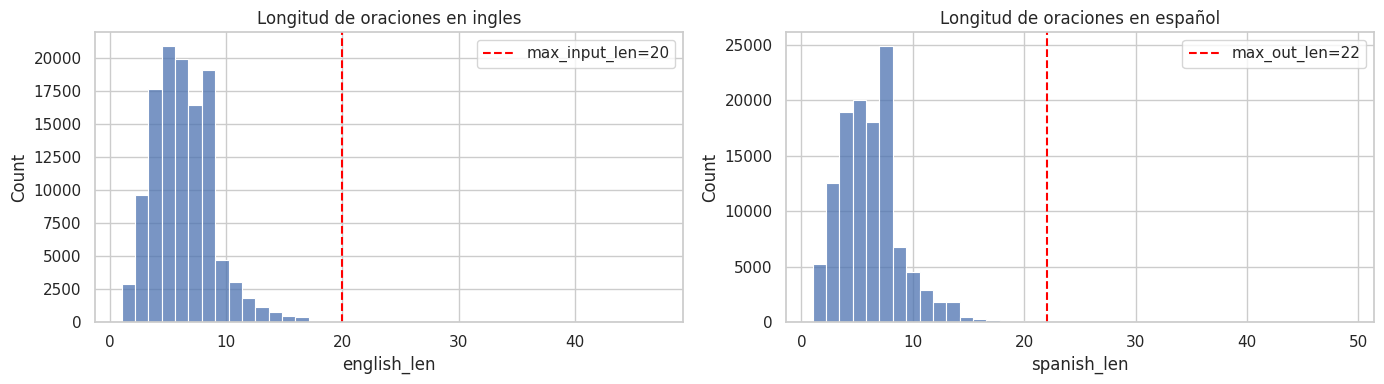

Oraciones que pasan el filtro de longitud: 118,818
Cobertura por longitud: 99.88%
Oraciones usadas luego de aplicar max_num_sentences: 20,000
Cobertura final usada para baseline: 16.81%


,english,spanish,english_len,spanish_len
0,You did not come to school yesterday.,Ayer no viniste a la escuela.,7,6
1,He speaks broken French.,Habla un francés entrecortado.,4,4
2,Tom didn't stay long.,Tom no se quedó mucho tiempo.,4,6
3,Who broke the mug?,¿Quién rompió la taza?,4,4
4,The customer isn't always right.,El cliente no siempre tiene razón.,5,6


In [102]:
length_summary = df_pairs[['english_len', 'spanish_len']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_pairs['english_len'], bins=40, ax=axes[0])
axes[0].axvline(config['max_input_len'], color='red', linestyle='--', label=f"max_input_len={config['max_input_len']}")
axes[0].set_title('Longitud de oraciones en ingles')
axes[0].legend()

sns.histplot(df_pairs['spanish_len'], bins=40, ax=axes[1])
axes[1].axvline(config['max_out_len'], color='red', linestyle='--', label=f"max_out_len={config['max_out_len']}")
axes[1].set_title('Longitud de oraciones en español')
axes[1].legend()

plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / 'dataset_length_profile.png', dpi=140, bbox_inches='tight')
plt.show()

df_length_filtered = df_pairs[
    (df_pairs['english_len'] <= config['max_input_len'])
    & (df_pairs['spanish_len'] <= config['max_out_len'] - 1)
].copy()
df_filtered = df_length_filtered.sample(frac=1, random_state=SEED).head(config['max_num_sentences']).reset_index(drop=True)

length_coverage = len(df_length_filtered) / len(df_pairs)
used_coverage = len(df_filtered) / len(df_pairs)
print(f'Oraciones que pasan el filtro de longitud: {len(df_length_filtered):,}')
print(f'Cobertura por longitud: {length_coverage:.2%}')
print(f'Oraciones usadas luego de aplicar max_num_sentences: {len(df_filtered):,}')
print(f'Cobertura final usada para baseline: {used_coverage:.2%}')
display(df_filtered.head())

### **longitudes del corpus**

El corpus completo contiene **118.964 pares** inglés-español. La longitud media es cercana a 6 tokens por oración en ambos idiomas, y los percentiles muestran que la gran mayoría de las frases son cortas, aprox el 99% de las frases tienen menos de 20 tokens en inglés y menos de 22 tokens en español.

Entonces un max y min len en 20 es razonable (22 para el decoder por el `<sos>` y `<eos>`).

### **Teacher forcing**

Para entrenar el decoder usamos la traducción real corrida una posición. Si la frase objetivo es `messi es campeon`, entonces el decoder aprende: `<sos> -> messi`, `messi -> es`, `es -> campeon`, `campeon -> <eos>`.

Por eso construimos dos targets: `decoder_input = <sos> messi es campeon` y `decoder_output = messi es campeon <eos>`.

In [103]:
input_sentences = df_filtered['english'].tolist()
output_sentences = (df_filtered['spanish'] + ' <eos>').tolist()
output_sentences_inputs = ('<sos> ' + df_filtered['spanish']).tolist()

sample_idx = 0
print('encoder_input:')
print(input_sentences[sample_idx])
print('\ndecoder_input:')
print(output_sentences_inputs[sample_idx])
print('\ndecoder_output:')
print(output_sentences[sample_idx])

encoder_input:
You did not come to school yesterday.

decoder_input:
<sos> Ayer no viniste a la escuela.

decoder_output:
Ayer no viniste a la escuela. <eos>


### **Tokenización y padding**

Seguimos la convención de clase: tokenizador separado para inglés y español, vocabulario máximo controlado por configuración y padding con longitud fija. En el decoder usamos padding `post` porque la generación ocurre de izquierda a derecha.

In [104]:
MAX_VOCAB_SIZE = config['max_vocab_size']
MAX_INPUT_LEN = config['max_input_len']
MAX_OUT_LEN = config['max_out_len']

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(['<sos>', '<eos>'] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_input = min(len(word2idx_inputs) + 1, MAX_VOCAB_SIZE)
num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=MAX_INPUT_LEN)
decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=MAX_OUT_LEN, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=MAX_OUT_LEN, padding='post')

print(f'Vocabulario EN: {len(word2idx_inputs):,} | usado: {num_words_input:,}')
print(f'Vocabulario ES: {len(word2idx_outputs):,} | usado: {num_words_output:,}')
print(f'encoder_input_sequences: {encoder_input_sequences.shape}')
print(f'decoder_input_sequences: {decoder_input_sequences.shape}')
print(f'decoder_output_sequences: {decoder_output_sequences.shape}')

preprocessing_artifacts = {
    'input_tokenizer': input_tokenizer,
    'output_tokenizer': output_tokenizer,
    'config': config,
    'config_name': ACTIVE_CONFIG_NAME,
    'num_words_input': num_words_input,
    'num_words_output': num_words_output,
    'max_input_len': MAX_INPUT_LEN,
    'max_out_len': MAX_OUT_LEN,
}

with open(ARTIFACTS_DIR / 'preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(preprocessing_artifacts, f)
df_filtered.to_csv(ARTIFACTS_DIR / 'filtered_pairs.csv', index=False)

print(f'Artefactos guardados en: {ARTIFACTS_DIR}')

Vocabulario EN: 6,811 | usado: 6,812
Vocabulario ES: 11,335 | usado: 8,000
encoder_input_sequences: (20000, 20)
decoder_input_sequences: (20000, 22)
decoder_output_sequences: (20000, 22)
Artefactos guardados en: /content/drive/MyDrive/NLP/Desafio_4/results/artifacts


### Análisis preliminar - tokenización

Con `MAX_VOCAB_SIZE=8000`, el vocabulario inglés queda cubierto con 6.811 palabras. En cambio, el español contiene 11.335 palabras, pero el modelo usa como máximo 8.000 índices.

Entonces varias palabras españolas poco frecuentes quedan fuera del vocabulario de salida. Eso limita lo que el decoder puede generar. Vemos cómo anda; si da el cuero con RAM/GPU, después subimos vocabulario español.


### **Preparación del dataset**

Armamos `tf.data.Dataset`: el modelo recibe `(encoder_input, decoder_input)` y el target queda como índices enteros, no one-hot. Con `val_split=0.15`, quedan 17.000 muestras para train y 3.000 para validación.

In [105]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, shuffle=False, mask_padding=False, repeat=False):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def format_sparse_target(enc, dec_in, dec_out):
        if mask_padding:
            sample_weight = tf.cast(tf.not_equal(dec_out, 0), tf.float32)
            return (enc, dec_in), dec_out, sample_weight
        return (enc, dec_in), dec_out

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(MAX_INPUT_LEN,), dtype=tf.int32),
            tf.TensorSpec(shape=(MAX_OUT_LEN,), dtype=tf.int32),
            tf.TensorSpec(shape=(MAX_OUT_LEN,), dtype=tf.int32),
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(n, 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(format_sparse_target, num_parallel_calls=tf.data.AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


BATCH_SIZE = config['batch_size']
val_split = config['val_split']
split_idx = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE,
    shuffle=True,
)

val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE,
    shuffle=False,
)

train_size = split_idx
val_size = len(encoder_input_sequences) - split_idx
steps_per_epoch = int(np.ceil(train_size / BATCH_SIZE))
validation_steps = int(np.ceil(val_size / BATCH_SIZE))

print(f'train_size: {train_size:,}')
print(f'val_size: {val_size:,}')
print(f'steps_per_epoch: {steps_per_epoch}')
print(f'validation_steps: {validation_steps}')
print(train_ds.element_spec)


train_size: 17,000
val_size: 3,000
steps_per_epoch: 266
validation_steps: 47
((TensorSpec(shape=(None, 20), dtype=tf.int32, name=None), TensorSpec(shape=(None, 22), dtype=tf.int32, name=None)), TensorSpec(shape=(None, 22), dtype=tf.int32, name=None))


### Análisis preliminar - ajuste sparse (importante y zarpado!)

Conviene usar target sparse: en vez de guardar `y` como `(64, 22, 8000)`, lo dejamos como índices `(64, 22)`. Es la misma clasificación por token, pero consume mucha menos memoria.

### Análisis preliminar - dataset

split 17.000 muestras para entrenamiento y 3.000 para validación. Con batch size 64 tenemos 266 batches de train y 47 de validación.

encoder `(64, 20)`, decoder input `(64, 22)` y target sparse `(64, 22)`. El modelo sigue prediciendo sobre 8.000 palabras por timestep, pero `y` queda como índices enteros y usamos `sparse_categorical_crossentropy`.

### **Arquitectura Encoder-Decoder**

In [106]:
def build_encoder(num_words_input, embed_dim, max_input_len, n_units, dropout):

    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=num_words_input,
        output_dim=embed_dim,
        input_length=max_input_len,
        name='encoder_embedding'
    )
    enc_emb = Dropout(dropout, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


def build_decoder(num_words_output, max_out_len, n_units, dropout, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(dropout, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True, name='decoder_lstm')
    dec_out, _, _ = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

In [107]:
EMBED_DIM = config['embedding_dim']
n_units = config['n_units']
dropout = config['dropout']

enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    num_words_input,
    EMBED_DIM,
    MAX_INPUT_LEN,
    n_units,
    dropout,
)

dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output,
    MAX_OUT_LEN,
    n_units,
    dropout,
    enc_states,
)

model = Model([enc_inputs, dec_inputs], dec_outputs, name=ACTIVE_CONFIG_NAME)

model.compile(
    loss=config['loss'],
    optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
    metrics=['accuracy'],
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "baseline_lstm_128_sparse"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 50)    │    340,600 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 22, 128)   │  1,024,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout     │ (None, 20, 50)    │          0 │ encoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 22, 128)   │          0 │ decoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     91,648 │ encoder_dropout[… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 22, 128), │    131,584 │ decoder_dropout[… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 22, 8000)  │  1,032,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,619,832 (9.99 MB)

 Trainable params: 2,619,832 (9.99 MB)

 Non-trainable params: 0 (0.00 B)

### Análisis preliminar - arquitectura

El baseline queda manejable, no es bestia: 2.619.832 parámetros entrenables. La salida `(None, 22, 8000)` coincide con la longitud del decoder y el vocabulario español usado.

Para primer entrenamiento está bien. Si queda corto, la comparación natural es subir `n_units` a 256 y ver mejora vs costo.

### **Entrenamiento**

Entrenamos la configuración activa con callbacks. Se guardan `best.weights.h5`, `last.weights.h5`, `history.csv` y `config.json` en Drive. Si se me cae el server se cargan los últimos pesos y se retoma desde el último epoch ddonde dejo.

In [108]:
def get_initial_epoch(history_csv):
    if not history_csv.exists():
        return 0
    history_df = pd.read_csv(history_csv)
    if history_df.empty or 'epoch' not in history_df.columns:
        return 0
    return int(history_df['epoch'].max()) + 1


def clear_run_artifacts(run_paths):
    for artifact_path in [
        run_paths['history_csv'],
        run_paths['best_weights'],
        run_paths['last_weights'],
        run_paths['predictions_csv'],
    ]:
        if artifact_path.exists():
            artifact_path.unlink()


def load_checkpoint_or_restart(model, run_paths):
    if not run_paths['last_weights'].exists():
        if run_paths['history_csv'].exists():
            print('Hay history.csv pero no hay last checkpoint. Reiniciamos esta configuracion.')
            clear_run_artifacts(run_paths)
        else:
            print('No hay checkpoint previo. Entrenamos desde cero.')
        return 0

    try:
        print(f"Cargando checkpoint: {run_paths['last_weights']}")
        model.load_weights(run_paths['last_weights'])
        return get_initial_epoch(run_paths['history_csv'])
    except ValueError as exc:
        print('Checkpoint incompatible con la arquitectura/tokenizacion actual.')
        print('Reiniciamos esta configuracion desde cero.')
        print(str(exc).split('\n')[0])
        clear_run_artifacts(run_paths)
        return 0


def load_existing_weights(model, run_paths):
    if run_paths['best_weights'].exists():
        model.load_weights(run_paths['best_weights'])
        print(f"Pesos cargados: {run_paths['best_weights']}")
        return True
    if run_paths['last_weights'].exists():
        model.load_weights(run_paths['last_weights'])
        print(f"Pesos cargados: {run_paths['last_weights']}")
        return True
    print('No hay checkpoint disponible para cargar.')
    return False


if RUN_BASELINE:
    callbacks, run_paths = build_callbacks(ACTIVE_CONFIG_NAME, config)

    if TRAIN_BASELINE:
        initial_epoch = load_checkpoint_or_restart(model, run_paths)
        print(f"initial_epoch: {initial_epoch}")
        print(f"epochs objetivo: {config['epochs']}")

        if initial_epoch >= config['epochs']:
            print('Esta configuración ya llegó al número de epochs definido.')
            hist = None
        else:
            hist = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=config['epochs'],
                initial_epoch=initial_epoch,
                callbacks=callbacks,
            )
    else:
        print('Entrenamiento baseline sparse salteado. Cargamos checkpoint para inferencia.')
        load_existing_weights(model, run_paths)
else:
    print('Seccion baseline sparse salteada.')


Entrenamiento baseline sparse salteado. Cargamos checkpoint para inferencia.
Pesos cargados: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/baseline_lstm_128_sparse/best.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


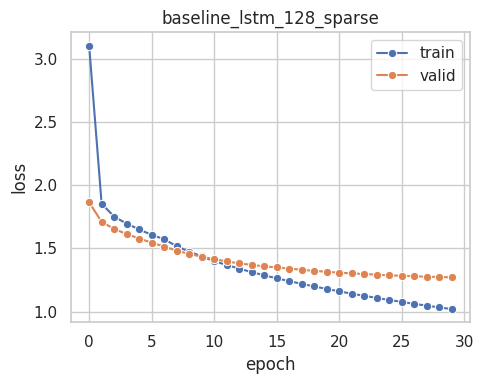

In [109]:
histories = load_histories([ACTIVE_CONFIG_NAME])
plot_loss_vs_val_loss_by_config(histories)


### Análisis - entrenamiento baseline sparse

El baseline sparse entrenó 30 epochs. La mejor validación volvió a quedar en el último epoch: `val_loss=1.2708` y `val_accuracy=0.7955`.

Los números son muy parecidos a la corrida anterior que no tenia el sparse loss y sacamos del analisis (`val_loss=1.2844`, `val_accuracy=0.7914`), incluso un poco mejores. 


### **Inferencia Modelo Seq2Seq**

Para traducir no usamos la secuencia real anterior. El decoder arranca con `<sos>`, predice un token, y ese token vuelve a entrar como input del paso siguiente hasta llegar a `<eos>`.

In [110]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer):
    enc_emb = enc_emb_layer(enc_inputs)
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )


if RUN_BASELINE:
    if run_paths['best_weights'].exists():
        model.load_weights(run_paths['best_weights'])
        print(f"Pesos cargados: {run_paths['best_weights']}")
    else:
        print('No se encontró best checkpoint. Se usan los pesos actuales del modelo.')

    encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer)
    decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)
else:
    print('Funciones de inferencia definidas. Baseline salteado.')


Pesos cargados: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/baseline_lstm_128_sparse/best.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [111]:
idx2word_input = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}


def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(MAX_OUT_LEN):
        output_tokens, h, c = decoder_model.predict([target_seq, h, c], verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target.get(idx, '<unk>'))
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=MAX_INPUT_LEN)
    return translate_sentence(seq)

### **Ejemplos de traducción**

Generamos ejemplos del dataset y frases nuevas para evaluar cualitativamente el modelo.  guardamos las predicciones en `predictions.csv`.

In [112]:
if RUN_BASELINE:
    sample_indices = [0, 1, 2, 3, 4]
    rows = []

    print('--- Ejemplos del dataset ---')
    for i in sample_indices:
        seq = encoder_input_sequences[i:i+1]
        pred = translate_sentence(seq)
        real = output_sentences[i].replace(' <eos>', '')
        rows.append({'english': input_sentences[i], 'spanish_real': real, 'spanish_pred': pred})
        print(f"EN: {input_sentences[i]}")
        print(f"ES real: {real}")
        print(f"ES pred: {pred}\n")

    print('--- Frases nuevas ---')
    new_sentences = [
        'Natural language processing is fun.',
        'This semester is killing me.',
        'Our soccer team is the best.',
        'Let\'s win another world cup',
        'I am very tired boss.',
    ]

    for sentence in new_sentences:
        pred = translate(sentence)
        rows.append({'english': sentence, 'spanish_real': None, 'spanish_pred': pred})
        print(f"EN: {sentence}")
        print(f"ES pred: {pred}\n")

    predictions_df = pd.DataFrame(rows)
    predictions_df.to_csv(run_paths['predictions_csv'], index=False)
    predictions_df
else:
    print('Salteado: ejemplos baseline sparse')


--- Ejemplos del dataset ---
EN: You did not come to school yesterday.
ES real: Ayer no viniste a la escuela.
ES pred: no quiero la ventana

EN: He speaks broken French.
ES real: Habla un francés entrecortado.
ES pred: él se casó con un minuto

EN: Tom didn't stay long.
ES real: Tom no se quedó mucho tiempo.
ES pred: tom no sabe nada

EN: Who broke the mug?
ES real: ¿Quién rompió la taza?
ES pred: la noche

EN: The customer isn't always right.
ES real: El cliente no siempre tiene razón.
ES pred: mi padre se ha ido a mary

--- Frases nuevas ---
EN: Natural language processing is fun.
ES pred: la gente es un poco

EN: This semester is killing me.
ES pred: este libro es

EN: Our soccer team is the best.
ES pred: el hombre está en el accidente

EN: Let's win another world cup
ES pred: te has vuelto

EN: I am very tired boss.
ES pred: me gusta la verdad



### Análisis preliminar - traducciones

Las traducciones del baseline son malas, al menos en contenido semántico. El modelo arma frases con forma de español, pero traduce mal.

Aparecen patrones frecuentes como “se ha".

Conclusión: el modelo aprendió algo de la distribución del español, pero traduce pesimo. Siguiente comparación: subir LSTM a 256 unidades.

### **Comparación con más unidades LSTM**

Entrenamos una segunda configuración con 256 unidades LSTM. La idea es ver si más capacidad mejora loss, accuracy y calidad de traducción.

In [113]:
if RUN_LSTM_256:
    ACTIVE_CONFIG_NAME = 'lstm_256_sparse'
    config = CONFIGS[ACTIVE_CONFIG_NAME]

    BATCH_SIZE = config['batch_size']
    val_split = config['val_split']
    split_idx = int(len(encoder_input_sequences) * (1 - val_split))

    train_ds = make_dataset(
        encoder_input_sequences[:split_idx],
        decoder_input_sequences[:split_idx],
        decoder_output_sequences[:split_idx],
        BATCH_SIZE,
        shuffle=True,
    )

    val_ds = make_dataset(
        encoder_input_sequences[split_idx:],
        decoder_input_sequences[split_idx:],
        decoder_output_sequences[split_idx:],
        BATCH_SIZE,
        shuffle=False,
    )

    train_size = split_idx
    val_size = len(encoder_input_sequences) - split_idx

    print(f'Config activa: {ACTIVE_CONFIG_NAME}')
    print(f'n_units: {config["n_units"]}')
    print(f'train_size: {train_size:,}')
    print(f'val_size: {val_size:,}')
else:
    print('Salteado: preparacion LSTM 256')


Config activa: lstm_256_sparse
n_units: 256
train_size: 17,000
val_size: 3,000


In [114]:
if RUN_LSTM_256:
    EMBED_DIM = config['embedding_dim']
    n_units = config['n_units']
    dropout = config['dropout']

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        num_words_input,
        EMBED_DIM,
        MAX_INPUT_LEN,
        n_units,
        dropout,
    )

    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output,
        MAX_OUT_LEN,
        n_units,
        dropout,
        enc_states,
    )

    model = Model([enc_inputs, dec_inputs], dec_outputs, name=ACTIVE_CONFIG_NAME)
    model.compile(
        loss=config['loss'],
        optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
        metrics=['accuracy'],
    )

    callbacks, run_paths = build_callbacks(ACTIVE_CONFIG_NAME, config)

    if TRAIN_LSTM_256:
        initial_epoch = load_checkpoint_or_restart(model, run_paths)
        print(f'params: {model.count_params():,}')
        print(f'initial_epoch: {initial_epoch}')
        print(f'epochs objetivo: {config["epochs"]}')

        if initial_epoch >= config['epochs']:
            print('Esta configuración ya llegó al número de epochs definido.')
            hist = None
        else:
            hist = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=config['epochs'],
                initial_epoch=initial_epoch,
                callbacks=callbacks,
            )
    else:
        print('Entrenamiento LSTM 256 salteado. Cargamos checkpoint para inferencia.')
        print(f'params: {model.count_params():,}')
        load_existing_weights(model, run_paths)
else:
    print('Seccion LSTM 256 salteada.')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Entrenamiento LSTM 256 salteado. Cargamos checkpoint para inferencia.
params: 5,284,280
Pesos cargados: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/lstm_256_sparse/best.weights.h5


### Análisis - LSTM 256

El modelo con 256 unidades mejora contra el baseline reentrenado: `val_loss` baja de `1.2708` a `1.2177` y `val_accuracy` sube de `0.7955` a `0.8008`.

También aumenta el gap train/validación: train accuracy llega a `0.8223` y val accuracy a `0.8008`. Mejora, pero empieza a verse más diferencia entre entrenamiento y validación. Para esas 30 epochs no veo un overfitting violento.


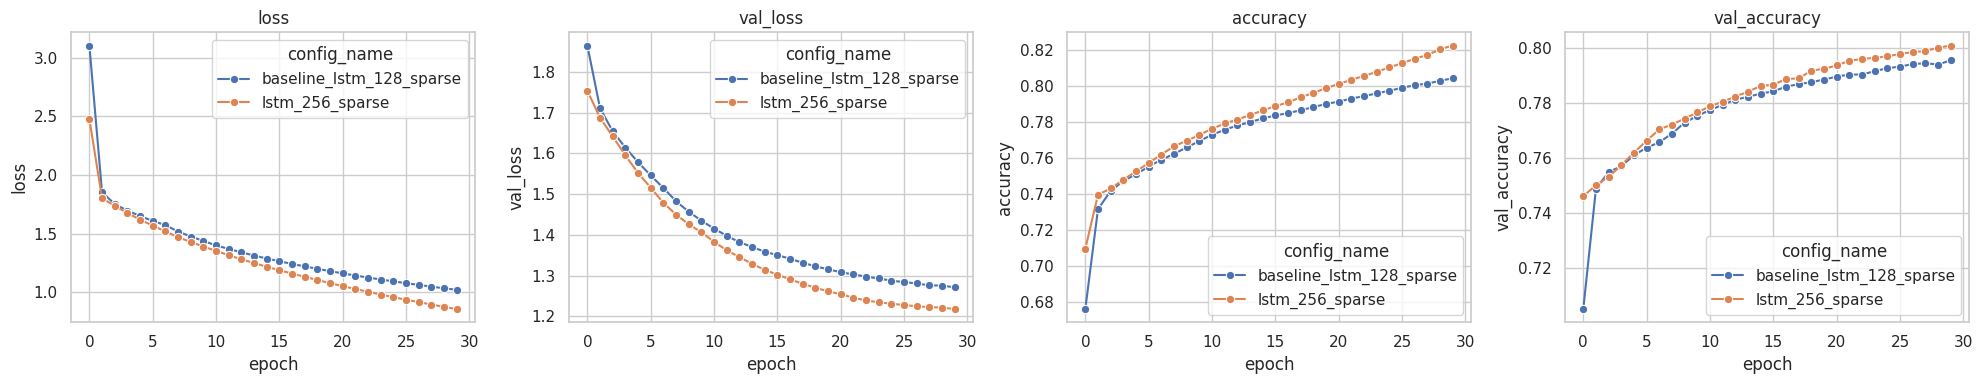

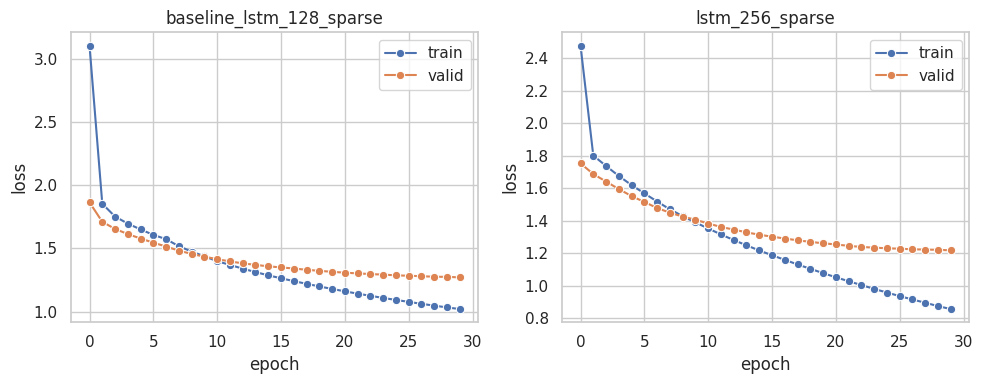

In [115]:
histories = load_histories(['baseline_lstm_128_sparse', 'lstm_256_sparse'])
plot_histories(histories)
plot_loss_vs_val_loss_by_config(histories)

### **Ejemplos de traducción LSTM 256**

Cargamos el mejor checkpoint de `lstm_256_sparse` y generamos los mismos ejemplos para comparar la calidad de traducción contra el baseline.

In [116]:
if RUN_LSTM_256:
    ACTIVE_CONFIG_NAME = 'lstm_256_sparse'
    config = CONFIGS[ACTIVE_CONFIG_NAME]
    run_paths = get_run_paths(ACTIVE_CONFIG_NAME)

    if run_paths['best_weights'].exists():
        model.load_weights(run_paths['best_weights'])
        print(f"Pesos cargados: {run_paths['best_weights']}")
    else:
        print('No se encontró best checkpoint. Se usan los pesos actuales del modelo.')

    encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer)
    decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)
else:
    print('Salteado: inferencia LSTM 256')


Pesos cargados: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/lstm_256_sparse/best.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [117]:
if RUN_LSTM_256:
    sample_indices = [0, 1, 2, 3, 4]
    rows = []

    print('--- Ejemplos del dataset | LSTM 256 ---')
    for i in sample_indices:
        seq = encoder_input_sequences[i:i+1]
        pred = translate_sentence(seq)
        real = output_sentences[i].replace(' <eos>', '')
        rows.append({'english': input_sentences[i], 'spanish_real': real, 'spanish_pred': pred})
        print(f"EN: {input_sentences[i]}")
        print(f"ES real: {real}")
        print(f"ES pred: {pred}\n")

    print('--- Frases nuevas | LSTM 256 ---')
    new_sentences = [
        'Natural language processing is fun.',
        'This semester is killing me.',
        'Our soccer team is the best.',
        "Let's win another world cup",
        'I am very tired boss.',
    ]

    for sentence in new_sentences:
        pred = translate(sentence)
        rows.append({'english': sentence, 'spanish_real': None, 'spanish_pred': pred})
        print(f"EN: {sentence}")
        print(f"ES pred: {pred}\n")

    predictions_df = pd.DataFrame(rows)
    predictions_df.to_csv(run_paths['predictions_csv'], index=False)
    predictions_df
else:
    print('Salteado: ejemplos LSTM 256')


--- Ejemplos del dataset | LSTM 256 ---
EN: You did not come to school yesterday.
ES real: Ayer no viniste a la escuela.
ES pred: no me gusta la casa

EN: He speaks broken French.
ES real: Habla un francés entrecortado.
ES pred: él tiene una buena persona

EN: Tom didn't stay long.
ES real: Tom no se quedó mucho tiempo.
ES pred: tom no se puede decidir a los

EN: Who broke the mug?
ES real: ¿Quién rompió la taza?
ES pred: quién se ha ido

EN: The customer isn't always right.
ES real: El cliente no siempre tiene razón.
ES pred: el hombre de no se ha ido

--- Frases nuevas | LSTM 256 ---
EN: Natural language processing is fun.
ES pred: la habitación es muy

EN: This semester is killing me.
ES pred: este es tan grande

EN: Our soccer team is the best.
ES pred: la gente de su es muy profunda

EN: Let's win another world cup
ES pred: lo que hicisteis es

EN: I am very tired boss.
ES pred: estoy muy preocupada por favor



### Análisis - traducciones LSTM 256

Aunque mejora `val_loss` y `val_accuracy`, las traducciones siguen siendo malas. El modelo genera español más razonable ("estoy muy preocupada por favor"), pero no conserva bien el significado del input.

En algunos casos reconoce partes sueltas (“estoy muy”, “este”), pero completa con frases genéricas. La mejora cuantitativa no alcanza para una mejora cualitativa.

### **Comparación de modelos**

El modelo de 256 unidades mejora las métricas frente al baseline de 128, pero ambos tienen baja fidelidad semántica en inferencia. Para la consigna, sirve como comparación de capacidad: más unidades ayudan en loss/accuracy, aunque no resuelven la calidad de traducción.

### **Más datos con LSTM 256**

Probamos el mismo modelo de 256 unidades, pero entrenando con 40.000 pares. La comparación queda acotada: misma arquitectura, mismo vocabulario máximo y mismas longitudes; solo cambia la cantidad de datos.

In [118]:
if RUN_LSTM_256_40K or RUN_OPTIONAL_GLOVE or RUN_OPTIONAL_BEAM:
    ACTIVE_CONFIG_NAME = 'lstm_256_sparse_40k'
    config = CONFIGS[ACTIVE_CONFIG_NAME]

    MAX_VOCAB_SIZE_INPUT = config.get('max_vocab_size_input', config['max_vocab_size'])
    MAX_VOCAB_SIZE_OUTPUT = config.get('max_vocab_size_output', config['max_vocab_size'])
    MAX_INPUT_LEN = config['max_input_len']
    MAX_OUT_LEN = config['max_out_len']


    df_filtered_40k = df_pairs[
        (df_pairs['english_len'] <= MAX_INPUT_LEN)
        & (df_pairs['spanish_len'] <= MAX_OUT_LEN - 1)
    ].copy()
    df_filtered_40k = df_filtered_40k.sample(frac=1, random_state=SEED).head(config['max_num_sentences']).reset_index(drop=True)

    input_sentences = df_filtered_40k['english'].tolist()
    output_sentences = (df_filtered_40k['spanish'] + ' <eos>').tolist()
    output_sentences_inputs = ('<sos> ' + df_filtered_40k['spanish']).tolist()

    input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE_INPUT)
    input_tokenizer.fit_on_texts(input_sentences)
    input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
    word2idx_inputs = input_tokenizer.word_index

    output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE_OUTPUT, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
    output_tokenizer.fit_on_texts(['<sos>', '<eos>'] + output_sentences)
    output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
    output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
    word2idx_outputs = output_tokenizer.word_index

    num_words_input = min(len(word2idx_inputs) + 1, MAX_VOCAB_SIZE_INPUT)
    num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE_OUTPUT)

    encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=MAX_INPUT_LEN)
    decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=MAX_OUT_LEN, padding='post')
    decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=MAX_OUT_LEN, padding='post')

    BATCH_SIZE = config['batch_size']
    val_split = config['val_split']
    split_idx = int(len(encoder_input_sequences) * (1 - val_split))
    mask_padding = config.get('target_format') == 'sparse_masked'

    train_ds = make_dataset(
        encoder_input_sequences[:split_idx],
        decoder_input_sequences[:split_idx],
        decoder_output_sequences[:split_idx],
        BATCH_SIZE,
        shuffle=True,
        mask_padding=mask_padding,
        repeat=True,
    )
    val_ds = make_dataset(
        encoder_input_sequences[split_idx:],
        decoder_input_sequences[split_idx:],
        decoder_output_sequences[split_idx:],
        BATCH_SIZE,
        shuffle=False,
        mask_padding=mask_padding,
        repeat=True,
    )

    train_size = split_idx
    val_size = len(encoder_input_sequences) - split_idx
    steps_per_epoch = int(np.ceil(train_size / BATCH_SIZE))
    validation_steps = int(np.ceil(val_size / BATCH_SIZE))

    df_filtered_40k.to_csv(ARTIFACTS_DIR / 'filtered_pairs_lstm_256_sparse_40k.csv', index=False)

    print(f'Config activa: {ACTIVE_CONFIG_NAME}')
    print(f'Pares usados: {len(df_filtered_40k):,}')
    print(f'Vocabulario EN: {len(word2idx_inputs):,} | usado: {num_words_input:,}')
    print(f'Vocabulario ES: {len(word2idx_outputs):,} | usado: {num_words_output:,}')
    print(f'target_format: {config["target_format"]}')
    print(f'mask_padding: {mask_padding}')
    print(f'train_size: {train_size:,}')
    print(f'val_size: {val_size:,}')
    print(f'steps_per_epoch: {steps_per_epoch}')
    print(f'validation_steps: {validation_steps}')
    print(train_ds.element_spec)
else:
    print('Salteado: preparacion LSTM 256 + 40k')


Config activa: lstm_256_sparse_40k
Pares usados: 40,000
Vocabulario EN: 9,048 | usado: 8,000
Vocabulario ES: 16,047 | usado: 12,000
target_format: sparse_masked
mask_padding: True
train_size: 34,000
val_size: 6,000
steps_per_epoch: 133
validation_steps: 24
((TensorSpec(shape=(None, 20), dtype=tf.int32, name=None), TensorSpec(shape=(None, 22), dtype=tf.int32, name=None)), TensorSpec(shape=(None, 22), dtype=tf.int32, name=None), TensorSpec(shape=(None, 22), dtype=tf.float32, name=None))


In [119]:
if RUN_LSTM_256_40K:
    EMBED_DIM = config['embedding_dim']
    n_units = config['n_units']
    dropout = config['dropout']

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        num_words_input, EMBED_DIM, MAX_INPUT_LEN, n_units, dropout
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, MAX_OUT_LEN, n_units, dropout, enc_states
    )

    model = Model([enc_inputs, dec_inputs], dec_outputs, name=ACTIVE_CONFIG_NAME)
    compile_args = {
        'loss': config['loss'],
        'optimizer': tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
    }
    if config.get('target_format') == 'sparse_masked':
        compile_args['weighted_metrics'] = ['accuracy']
    else:
        compile_args['metrics'] = ['accuracy']

    model.compile(**compile_args)

    callbacks, run_paths = build_callbacks(ACTIVE_CONFIG_NAME, config)

    EXPECTED_RUN_VERSION = 'vocab12k_masked_repeat_bs256_v3'
    run_version_path = run_paths['history_csv'].parent / 'run_version.txt'
    current_run_version = run_version_path.read_text().strip() if run_version_path.exists() else ''

    if TRAIN_LSTM_256_40K and current_run_version != EXPECTED_RUN_VERSION:
        print('Limpiando checkpoints/history anteriores de LSTM 256 + 40k.')
        print('Motivo: la primera corrida no enmascaraba padding y generaba traducciones vacias.')
        clear_run_artifacts(run_paths)
        run_version_path.write_text(EXPECTED_RUN_VERSION)

    if TRAIN_LSTM_256_40K:
        initial_epoch = load_checkpoint_or_restart(model, run_paths)
        print(f'params: {model.count_params():,}')
        print(f'initial_epoch: {initial_epoch}')
        print(f'epochs objetivo: {config["epochs"]}')

        if initial_epoch >= config['epochs']:
            print('Esta configuración ya llegó al número de epochs definido.')
            hist = None
        else:
            hist = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=config['epochs'],
                initial_epoch=initial_epoch,
                callbacks=callbacks,
                steps_per_epoch=steps_per_epoch,
                validation_steps=validation_steps,
            )
    else:
        print('Entrenamiento LSTM 256 + 40k salteado. Cargamos checkpoint para inferencia.')
        print(f'params: {model.count_params():,}')
        load_existing_weights(model, run_paths)
else:
    print('Seccion LSTM 256 + 40k salteada.')


Entrenamiento LSTM 256 + 40k salteado. Cargamos checkpoint para inferencia.
params: 7,395,680
Pesos cargados: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/lstm_256_sparse_40k/best.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### **Ejemplos de traducción LSTM 256 + 40k**

Cargamos el mejor checkpoint del modelo 40k corregido. Esta versión usa más vocabulario en español y máscara de padding en la loss.


In [120]:
if RUN_LSTM_256_40K:
    ACTIVE_CONFIG_NAME = 'lstm_256_sparse_40k'
    config = CONFIGS[ACTIVE_CONFIG_NAME]
    run_paths = get_run_paths(ACTIVE_CONFIG_NAME)

    if run_paths['best_weights'].exists():
        model.load_weights(run_paths['best_weights'])
        print(f"Pesos cargados: {run_paths['best_weights']}")
    else:
        print('No se encontró best checkpoint. Se usan los pesos actuales del modelo.')

    encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer)
    decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)
else:
    print('Salteado: inferencia LSTM 256 + 40k')


Pesos cargados: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/lstm_256_sparse_40k/best.weights.h5


In [121]:
if RUN_LSTM_256_40K:
    sample_indices = [0, 1, 2, 3, 4]
    rows = []

    print('--- Ejemplos del dataset | LSTM 256 + 40k ---')
    for i in sample_indices:
        seq = encoder_input_sequences[i:i+1]
        pred = translate_sentence(seq)
        real = output_sentences[i].replace(' <eos>', '')
        rows.append({'english': input_sentences[i], 'spanish_real': real, 'spanish_pred': pred})
        print(f"EN: {input_sentences[i]}")
        print(f"ES real: {real}")
        print(f"ES pred: {pred}\n")

    print('--- Frases nuevas | LSTM 256 + 40k ---')
    new_sentences = [
        'Natural language processing is fun.',
        'This semester is killing me.',
        'Our soccer team is the best.',
        "Let's win another world cup",
        'I am very tired boss.',
    ]

    for sentence in new_sentences:
        pred = translate(sentence)
        rows.append({'english': sentence, 'spanish_real': None, 'spanish_pred': pred})
        print(f"EN: {sentence}")
        print(f"ES pred: {pred}\n")

    predictions_df = pd.DataFrame(rows)
    predictions_df.to_csv(run_paths['predictions_csv'], index=False)
    print(predictions_df.to_string(index=False))
else:
    print('Salteado: ejemplos LSTM 256 + 40k')


--- Ejemplos del dataset | LSTM 256 + 40k ---
EN: You did not come to school yesterday.
ES real: Ayer no viniste a la escuela.
ES pred: a todo que casa el ya

EN: He speaks broken French.
ES real: Habla un francés entrecortado.
ES pred: él se viejo montón en el así

EN: Tom didn't stay long.
ES real: Tom no se quedó mucho tiempo.
ES pred: tom a se fueron no los incluso

EN: Who broke the mug?
ES real: ¿Quién rompió la taza?
ES pred: el así se está en la allí

EN: The customer isn't always right.
ES real: El cliente no siempre tiene razón.
ES pred: el quería a es tu

--- Frases nuevas | LSTM 256 + 40k ---
EN: Natural language processing is fun.
ES pred: el así es tu he

EN: This semester is killing me.
ES pred: este es un están de

EN: Our soccer team is the best.
ES pred: el quería es el ruido buen

EN: Let's win another world cup
ES pred: mucho se hagas un están

EN: I am very tired boss.
ES pred: tiene tu he

                              english                       spanish_real   

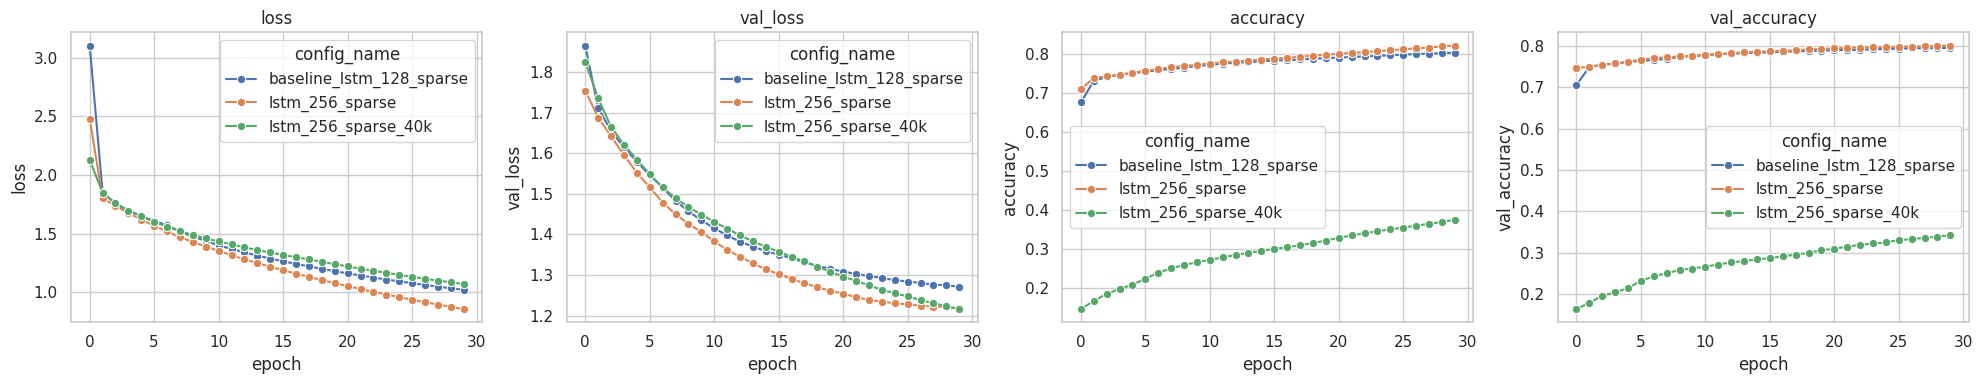

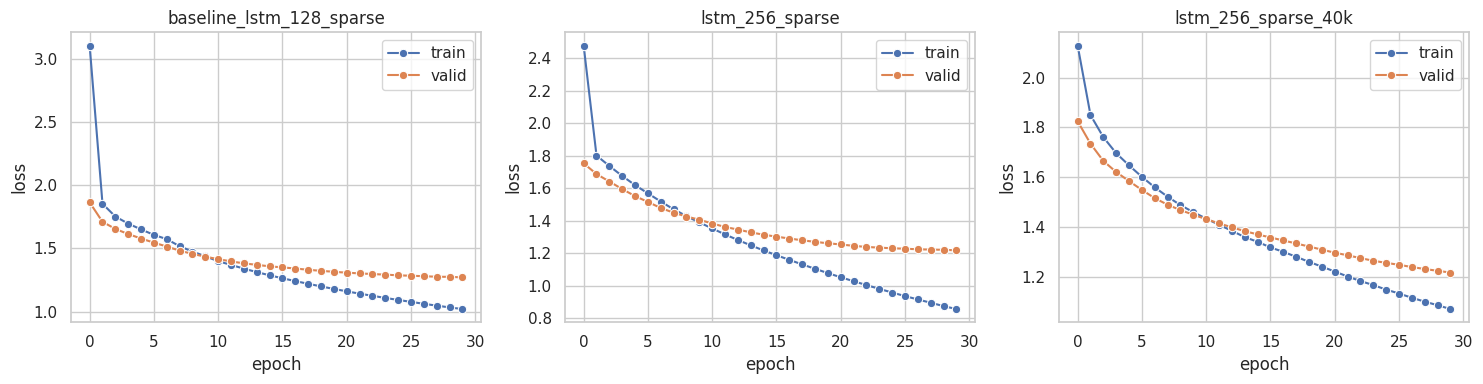

In [122]:
histories = load_histories(['baseline_lstm_128_sparse', 'lstm_256_sparse', 'lstm_256_sparse_40k'])
plot_histories(histories)
plot_loss_vs_val_loss_by_config(histories)


### Análisis - LSTM 256 + 40k

La primera corrida de este modelo dio métricas demasiado buenas, pero traducciones vacías. El problema era que la loss y la accuracy estaban dominadas por padding.

En la versión corregida usamos 40k pares, LSTM 256, vocabulario español de 12k y máscara de padding. La métrica baja mucho porque ahora no cuenta padding: `val_accuracy=0.3419`, `val_loss=1.2162`.

El `val_loss` queda prácticamente igual al LSTM 256 con 20k (`1.2177`) y mejor que el baseline (`1.2708`). Pero las traducciones siguen siendo malas. Ya no devuelve vacío, pero genera frases con palabras frecuentes y poco sentido semántico.


### **Opcionales: embeddings y beam search**

Cerramos con dos opcionales: inicializar el embedding del encoder con GloVe y comparar greedy search contra beam search.


### **Embedding preentrenado en el encoder**

usamos GloVe para inicializar la capa `Embedding` del encoder en inglés. El resto sigue siendo el mismo encoder-decoder LSTM.

Seguimos la convención de clase: GloVe tiene 50 dimensiones y queda congelado. El decoder sigue aprendiendo su propio embedding porque las palabras de salida están en español y se complejizarìa bastante si quisieramos meter un embedding entrenado, en el contexto de este desafio.


In [123]:
if RUN_OPTIONAL_GLOVE:
    def _is_valid_pickle(path):
        try:
            with open(path, 'rb') as f:
                head = f.read(20)
            return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
        except Exception:
            return False


    def load_glove_embeddings(pkl_path):
        max_bytes = 2**28 - 1
        raw = bytearray()
        sz = pkl_path.stat().st_size
        with open(pkl_path, 'rb') as f:
            for _ in range(0, sz, max_bytes):
                raw += f.read(max_bytes)
        embeddings = pickle.loads(raw)
        idx_array = np.arange(embeddings.shape[0])
        word2idx_glove = dict(zip(embeddings['word'], idx_array))
        return embeddings, word2idx_glove


    def get_word_embedding(word, embeddings, word2idx_glove, n_features=50):
        i = word2idx_glove.get(word, -1)
        return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)


    def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove, nb_words, embed_dim=50):
        matrix = np.zeros((nb_words, embed_dim))
        for word, i in word2idx_inputs.items():
            if i < nb_words:
                matrix[i] = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
        return matrix


    GLOVE_PATH = DATA_DIR / 'gloveembedding.pkl'
    GLOVE_FILE_ID = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

    if not GLOVE_PATH.exists() or not _is_valid_pickle(GLOVE_PATH):
        print('Descargando gloveembedding.pkl...')
        try:
            import gdown
            gdown.download(id=GLOVE_FILE_ID, output=str(GLOVE_PATH), quiet=False)
        except Exception:
            import subprocess
            subprocess.run([
                'curl', '-L', '-o', str(GLOVE_PATH),
                f'https://drive.google.com/u/0/uc?id={GLOVE_FILE_ID}&export=download&confirm=t'
            ], check=True)

    if not _is_valid_pickle(GLOVE_PATH):
        raise ValueError('El archivo GloVe descargado no es un pickle valido.')

    glove_embeddings, glove_word2idx = load_glove_embeddings(GLOVE_PATH)
    embedding_matrix = build_embedding_matrix(
        word2idx_inputs,
        glove_embeddings,
        glove_word2idx,
        num_words_input,
        config['embedding_dim'],
    )

    zero_embeddings = np.sum(np.sum(embedding_matrix ** 2, axis=1) == 0)
    print(f'GloVe path: {GLOVE_PATH}')
    print(f'embedding_matrix shape: {embedding_matrix.shape}')
    print(f'embeddings nulos: {zero_embeddings:,}')
else:
    print('Salteado: descarga/carga GloVe')


GloVe path: /content/drive/MyDrive/NLP/Desafio_4/data/gloveembedding.pkl
embedding_matrix shape: (8000, 50)
embeddings nulos: 368


In [124]:
if RUN_OPTIONAL_GLOVE:
    OPTIONAL_CONFIG_NAME = 'optional_glove_lstm_256_40k'
    optional_config = dict(config)
    optional_config['use_glove_encoder'] = True
    optional_config['epochs'] = 15
    optional_config['patience_early_stop'] = 3
    optional_config['patience_reduce_lr'] = 2


    def build_encoder_glove(num_words_input, embed_dim, embedding_matrix, max_input_len, n_units, dropout):
        enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')
        enc_emb_layer = Embedding(
            input_dim=num_words_input,
            output_dim=embed_dim,
            input_length=max_input_len,
            weights=[embedding_matrix],
            trainable=False,
            name='encoder_embedding_glove'
        )
        enc_emb = Dropout(dropout, name='encoder_dropout')(enc_emb_layer(enc_inputs))
        enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
        _, state_h, state_c = enc_lstm_layer(enc_emb)
        return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder_glove(
        num_words_input,
        optional_config['embedding_dim'],
        embedding_matrix,
        MAX_INPUT_LEN,
        optional_config['n_units'],
        optional_config['dropout'],
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output,
        MAX_OUT_LEN,
        optional_config['n_units'],
        optional_config['dropout'],
        enc_states,
    )

    model = Model([enc_inputs, dec_inputs], dec_outputs, name=OPTIONAL_CONFIG_NAME)
    compile_args = {
        'loss': optional_config['loss'],
        'optimizer': tf.keras.optimizers.Adam(learning_rate=optional_config['learning_rate']),
    }
    if optional_config.get('target_format') == 'sparse_masked':
        compile_args['weighted_metrics'] = ['accuracy']
    else:
        compile_args['metrics'] = ['accuracy']

    model.compile(**compile_args)

    callbacks, run_paths = build_callbacks(OPTIONAL_CONFIG_NAME, optional_config)

    EXPECTED_OPTIONAL_GLOVE_VERSION = 'glove_40k_repeat_bs256_v1'
    run_version_path = run_paths['history_csv'].parent / 'run_version.txt'
    current_run_version = run_version_path.read_text().strip() if run_version_path.exists() else ''

    if TRAIN_OPTIONAL_GLOVE and current_run_version != EXPECTED_OPTIONAL_GLOVE_VERSION:
        print('Limpiando checkpoints/history anteriores de GloVe.')
        print('Motivo: una corrida previa uso un dataset no repetido y dejo epochs en cero.')
        clear_run_artifacts(run_paths)
        run_version_path.write_text(EXPECTED_OPTIONAL_GLOVE_VERSION)

    if TRAIN_OPTIONAL_GLOVE:
        initial_epoch = load_checkpoint_or_restart(model, run_paths)
        print(f'params: {model.count_params():,}')
        print(f'initial_epoch: {initial_epoch}')
        print(f'epochs objetivo: {optional_config["epochs"]}')

        if initial_epoch >= optional_config['epochs']:
            print('Esta configuración ya llegó al número de epochs definido.')
            hist = None
        else:
            hist = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=optional_config['epochs'],
                initial_epoch=initial_epoch,
                callbacks=callbacks,
                steps_per_epoch=steps_per_epoch,
                validation_steps=validation_steps,
            )
    else:
        print('Entrenamiento GloVe salteado. Cargamos checkpoint para inferencia/beam.')
        print(f'params: {model.count_params():,}')
        load_existing_weights(model, run_paths)
else:
    print('Salteado: entrenamiento opcional GloVe')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Entrenamiento GloVe salteado. Cargamos checkpoint para inferencia/beam.
params: 7,395,680
Pesos cargados: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/optional_glove_lstm_256_40k/best.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### **Beam search**

Probamos beam search sobre el mejor modelo (`LSTM 256 + 40k`) y la variante con embedding GloVe en el encoder.

Greedy elige la palabra más probable en cada instante. Beam search se queda con la secuencia de mayor probabilidad acumulada.


In [125]:
if RUN_OPTIONAL_BEAM:
    beam_config_name = 'lstm_256_sparse_40k'
    beam_config = CONFIGS[beam_config_name]
    expected_num_words_input = beam_config.get('max_vocab_size_input', beam_config['max_vocab_size'])
    expected_num_words_output = beam_config.get('max_vocab_size_output', beam_config['max_vocab_size'])

    if num_words_input != expected_num_words_input or num_words_output != expected_num_words_output:
        raise ValueError(
            'Las variables activas no corresponden al experimento 40k. '
            'Corri desde la celda "Más datos con LSTM 256" antes de beam search. '
            f'Actual: input={num_words_input}, output={num_words_output}. '
            f'Esperado: input={expected_num_words_input}, output={expected_num_words_output}.'
        )

    idx2word_target = {v: k for k, v in word2idx_outputs.items()}


    def translate_sentence_greedy_model(input_seq, encoder_model, decoder_model):
        h, c = encoder_model.predict(input_seq, verbose=0)
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = word2idx_outputs['<sos>']
        eos = word2idx_outputs['<eos>']

        output_sentence = []
        for _ in range(MAX_OUT_LEN):
            output_tokens, h, c = decoder_model.predict([target_seq, h, c], verbose=0)
            idx = np.argmax(output_tokens[0, 0, :])
            if idx == eos:
                break
            if idx > 0:
                output_sentence.append(idx2word_target.get(idx, '<unk>'))
            target_seq[0, 0] = idx
        return ' '.join(output_sentence)


    def translate_sentence_beam_model(input_seq, encoder_model, decoder_model, beam_width=3):
        h, c = encoder_model.predict(input_seq, verbose=0)
        sos = word2idx_outputs['<sos>']
        eos = word2idx_outputs['<eos>']
        beams = [([sos], 0.0, h, c, False)]

        for _ in range(MAX_OUT_LEN):
            candidates = []
            for tokens, score, h_prev, c_prev, finished in beams:
                if finished:
                    candidates.append((tokens, score, h_prev, c_prev, finished))
                    continue

                target_seq = np.array([[tokens[-1]]])
                output_tokens, h_next, c_next = decoder_model.predict([target_seq, h_prev, c_prev], verbose=0)
                probs = output_tokens[0, 0, :]
                top_idx = np.argsort(probs)[-beam_width:][::-1]

                for idx in top_idx:
                    new_score = score + np.log(probs[idx] + 1e-9)
                    candidates.append((tokens + [idx], new_score, h_next, c_next, idx == eos))

            beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]
            if all(item[4] for item in beams):
                break

        best_tokens = beams[0][0][1:]
        words = []
        for idx in best_tokens:
            if idx == eos:
                break
            if idx > 0:
                words.append(idx2word_target.get(idx, '<unk>'))
        return ' '.join(words), beams[0][1]


    def translate_with_model(text, encoder_model, decoder_model, method='greedy', beam_width=3):
        seq = input_tokenizer.texts_to_sequences([text])
        seq = pad_sequences(seq, maxlen=MAX_INPUT_LEN)
        if method == 'beam':
            return translate_sentence_beam_model(seq, encoder_model, decoder_model, beam_width=beam_width)
        return translate_sentence_greedy_model(seq, encoder_model, decoder_model), None


    beam_models = {}
    beam_run_paths = get_run_paths(beam_config_name)

    enc_inputs_40k, enc_states_40k, enc_emb_layer_40k, enc_lstm_layer_40k = build_encoder(
        expected_num_words_input,
        beam_config['embedding_dim'],
        MAX_INPUT_LEN,
        beam_config['n_units'],
        beam_config['dropout'],
    )
    dec_inputs_40k, dec_outputs_40k, dec_emb_layer_40k, dec_lstm_layer_40k, dec_dense_layer_40k = build_decoder(
        expected_num_words_output,
        MAX_OUT_LEN,
        beam_config['n_units'],
        beam_config['dropout'],
        enc_states_40k,
    )
    model_40k = Model([enc_inputs_40k, dec_inputs_40k], dec_outputs_40k, name=beam_config_name)

    if beam_run_paths['best_weights'].exists():
        model_40k.load_weights(beam_run_paths['best_weights'])
        encoder_model_40k = build_encoder_inference(enc_inputs_40k, enc_emb_layer_40k, enc_lstm_layer_40k)
        decoder_model_40k = build_decoder_inference(dec_emb_layer_40k, dec_lstm_layer_40k, dec_dense_layer_40k, beam_config['n_units'])
        beam_models[beam_config_name] = (encoder_model_40k, decoder_model_40k)
        print(f"Modelo para beam cargado: {beam_run_paths['best_weights']}")
    else:
        print('No se encontró checkpoint del modelo LSTM 256 + 40k para beam.')

    if RUN_OPTIONAL_GLOVE:
        glove_run_paths = get_run_paths(OPTIONAL_CONFIG_NAME)
        if glove_run_paths['best_weights'].exists():
            model.load_weights(glove_run_paths['best_weights'])
            encoder_model_glove = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer)
            decoder_model_glove = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, optional_config['n_units'])
            beam_models[OPTIONAL_CONFIG_NAME] = (encoder_model_glove, decoder_model_glove)
            print(f"Variante con embedding GloVe para beam cargada: {glove_run_paths['best_weights']}")
        else:
            print('No se encontró checkpoint de la variante con GloVe para beam.')
else:
    print('Salteado: funciones beam search')


Modelo para beam cargado: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/lstm_256_sparse_40k/best.weights.h5
Variante con embedding GloVe para beam cargada: /content/drive/MyDrive/NLP/Desafio_4/checkpoints/optional_glove_lstm_256_40k/best.weights.h5


=== GREEDY VS BEAM SEARCH ===
--- lstm_256_sparse_40k ---
EN: Natural language processing is fun.
Greedy: el mundo es muy bien
Beam 3: el problema es muy
Score: -9.9668

EN: This semester is killing me.
Greedy: este es un poco de
Beam 3: este es el trabajo
Score: -9.9320

EN: Our soccer team is the best.
Greedy: el hombre es el único pasado
Beam 3: el hombre es la última vez
Score: -11.7624

EN: Let's win another world cup
Greedy: ellos se pueden un poco
Beam 3: tenemos un poco más
Score: -10.6001

EN: I am very tired boss.
Greedy: estoy muy bien
Beam 3: estoy muy bien
Score: -6.5778

--- optional_glove_lstm_256_40k ---
EN: Natural language processing is fun.
Greedy: la es muy importante
Beam 3: cuál es tu libro
Score: -9.2381

EN: This semester is killing me.
Greedy: este es el día de mí
Beam 3: esto no es demasiado
Score: -10.2587

EN: Our soccer team is the best.
Greedy: la mayoría de la vida es la escuela
Beam 3: nuestro libro es el libro
Score: -12.3270

EN: Let's win another worl

,modelo,frase EN,greedy,beam width=3,score beam
0,LSTM 256 + 40k,Natural language processing is fun.,el mundo es muy bien,el problema es muy,-9.967000
1,LSTM 256 + 40k,This semester is killing me.,este es un poco de,este es el trabajo,-9.932000
2,LSTM 256 + 40k,Our soccer team is the best.,el hombre es el único pasado,el hombre es la última vez,-11.762000
3,LSTM 256 + 40k,Let's win another world cup,ellos se pueden un poco,tenemos un poco más,-10.600000
4,LSTM 256 + 40k,I am very tired boss.,estoy muy bien,estoy muy bien,-6.578000
5,LSTM 256 + 40k + GloVe encoder,Natural language processing is fun.,la es muy importante,cuál es tu libro,-9.238000
6,LSTM 256 + 40k + GloVe encoder,This semester is killing me.,este es el día de mí,esto no es demasiado,-10.259000
7,LSTM 256 + 40k + GloVe encoder,Our soccer team is the best.,la mayoría de la vida es la escuela,nuestro libro es el libro,-12.327000
8,LSTM 256 + 40k + GloVe encoder,Let's win another world cup,el libro,hay el libro,-9.810000
9,LSTM 256 + 40k + GloVe encoder,I am very tired boss.,estoy muy cansado,estoy muy cansado,-5.483000


Tabla guardada en: /content/drive/MyDrive/NLP/Desafio_4/results/beam_search_comparison_table.png


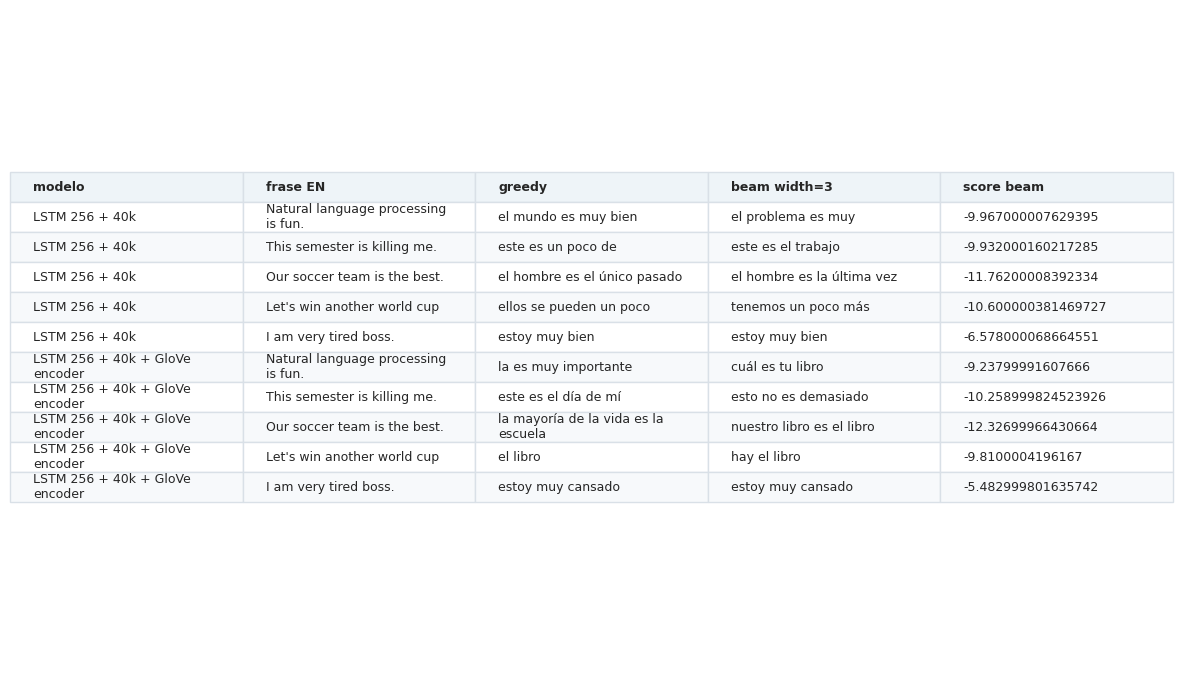

In [126]:
if RUN_OPTIONAL_BEAM:
    from textwrap import fill

    sample_sentences = [
        'Natural language processing is fun.',
        'This semester is killing me.',
        'Our soccer team is the best.',
        "Let's win another world cup",
        'I am very tired boss.',
    ]

    rows = []
    print('=== GREEDY VS BEAM SEARCH ===')
    for model_name, (encoder_model_eval, decoder_model_eval) in beam_models.items():
        print(f'--- {model_name} ---')
        for sentence in sample_sentences:
            greedy, _ = translate_with_model(sentence, encoder_model_eval, decoder_model_eval, method='greedy')
            beam, score = translate_with_model(sentence, encoder_model_eval, decoder_model_eval, method='beam', beam_width=3)
            rows.append({
                'model': model_name,
                'english': sentence,
                'greedy': greedy,
                'beam_width_3': beam,
                'beam_score': score,
            })
            print(f'EN: {sentence}')
            print(f'Greedy: {greedy}')
            print(f'Beam 3: {beam}')
            print(f'Score: {score:.4f}\n')

    beam_df = pd.DataFrame(rows)
    beam_output_path = PREDICTIONS_DIR / 'beam_search_comparison.csv'
    beam_df.to_csv(beam_output_path, index=False)

    model_labels = {
        'lstm_256_sparse_40k': 'LSTM 256 + 40k',
        'optional_glove_lstm_256_40k': 'LSTM 256 + 40k + GloVe encoder',
    }
    pretty_beam = beam_df.copy()
    pretty_beam['modelo'] = pretty_beam['model'].map(model_labels).fillna(pretty_beam['model'])
    pretty_beam = pretty_beam[['modelo', 'english', 'greedy', 'beam_width_3', 'beam_score']].rename(columns={
        'english': 'frase EN',
        'beam_width_3': 'beam width=3',
        'beam_score': 'score beam',
    })
    pretty_beam['score beam'] = pretty_beam['score beam'].round(3)

    print('=== TABLA GREEDY VS BEAM ===')
    display(pretty_beam.style.set_properties(**{
        'white-space': 'pre-wrap',
        'text-align': 'left',
    }).set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('vertical-align', 'top')]},
    ]))

    wrapped_table = pretty_beam.copy()
    for col in ['frase EN', 'greedy', 'beam width=3']:
        wrapped_table[col] = wrapped_table[col].apply(lambda value: fill(str(value), width=28))
    wrapped_table['modelo'] = wrapped_table['modelo'].apply(lambda value: fill(str(value), width=22))

    fig, ax = plt.subplots(figsize=(15, 0.65 * len(wrapped_table) + 2))
    ax.axis('off')
    table = ax.table(
        cellText=wrapped_table.values,
        colLabels=wrapped_table.columns,
        loc='center',
        cellLoc='left',
        colLoc='left',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#d9e0e7')
        if row == 0:
            cell.set_facecolor('#eef4f8')
            cell.set_text_props(weight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#f7f9fb')

    table_path = RESULTS_DIR / 'beam_search_comparison_table.png'
    print(f'Tabla guardada en: {table_path}')
else:
    print('Salteado: ejemplos beam search')


### Análisis - Glove y beam vs greedy

GloVe mejora un poco las métricas del modelo 40k: `val_loss` baja de `1.2162` a `1.1441` y `val_accuracy` sube de `0.3419` a `0.3649`.

En traducciones, la mejora cualitativa es irregular. El caso más claro es `I am very tired boss.`: sin GloVe el modelo genera `estoy muy bien`; con GloVe genera `estoy muy cansado`. En ese ejemplo, greedy y beam dan lo mismo dentro de cada modelo.

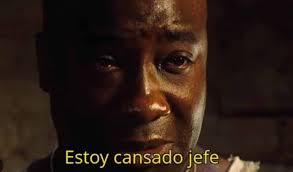

Beam search no mejora de forma consistente. A veces cambia la frase, pero no necesariamente la vmejora. Busca la secuencia más probable según el modelo, asi que si el modelo aprendió pobremente, beam puede elegir una frase más probable pero malisima igual.
